In [11]:
!git clone https://github.com/soltanianzadeh/STNeuroNet /kaggle/working/STNeuroNet -q
import os
print(os.listdir('/kaggle/working/STNeuroNet/Markings/ABO'))

fatal: destination path '/kaggle/working/STNeuroNet' already exists and is not an empty directory.
['Layer175', 'Layer275']


In [12]:
import os

for root, dirs, files in os.walk('/kaggle/working/STNeuroNet/Markings/ABO'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_501836392.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_501271265.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_501704220.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_502115959.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_510517131.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_545446482.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_502205092.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_504637623.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_540684467.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_510514474.mat
/kaggle/working/STNeuroNet/Markings/ABO/Layer175/Allen/Masks_502115959.mat
/kagg

In [14]:
import h5py

with h5py.File('/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_501836392.mat', 'r') as f:
    print(list(f.keys()))

['FinalMasks', 'FinalTraces']


In [15]:
with h5py.File('/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_501836392.mat', 'r') as f:
    masks = f['FinalMasks'][:]
    print(masks.shape, masks.dtype)

(198, 487, 487) float64


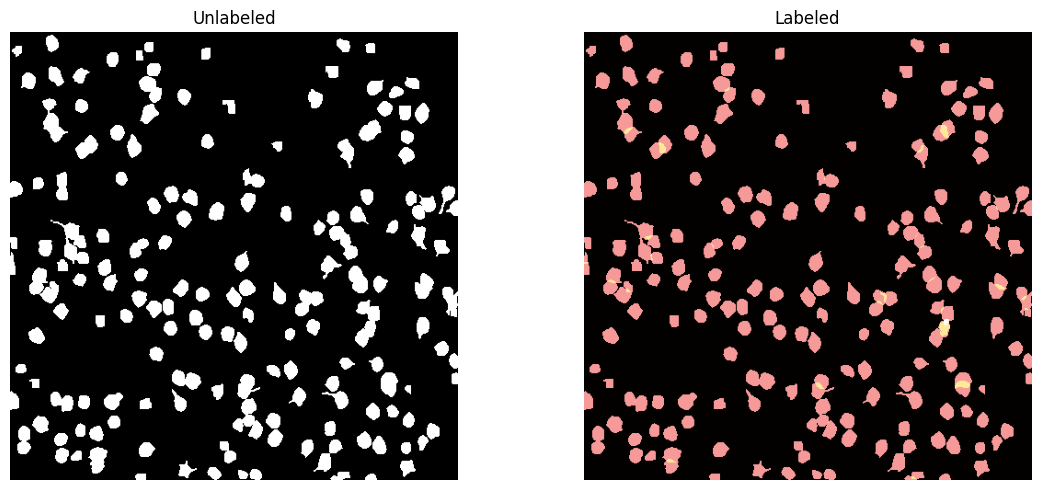

In [16]:
import numpy as np
import matplotlib.pyplot as plt

with h5py.File('/kaggle/working/STNeuroNet/Markings/ABO/Layer175/FinalGT/FinalMasks_FPremoved_501836392.mat', 'r') as f:
    masks = f['FinalMasks'][:]

mean_img = masks.max(axis=0)

labeled_img = np.zeros((*mean_img.shape, 3))
labeled_img[..., 0] = mean_img / mean_img.max()

contours = np.zeros(mean_img.shape)
for m in masks:
    contours += m

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mean_img, cmap='gray')
axes[0].set_title('Unlabeled')
axes[0].axis('off')

axes[1].imshow(mean_img, cmap='gray')
axes[1].imshow(contours, alpha=0.4, cmap='hot')
axes[1].set_title('Labeled')
axes[1].axis('off')

plt.tight_layout()
plt.show()